# Deep Momentum Networks: Sharpe Loss and Seed Variance

Lim, Zohren & Roberts (2019) replace the two-step momentum pipeline (estimate a trend, then size a position) with one network trained **directly on the Sharpe ratio**. Wood, Giegerich, Roberts & Zohren (2021) do the same with a Temporal Fusion Transformer. The lecture's own critique of both is the reason this notebook exists:

- the published models were fit on ~88 futures and decades of daily bars (Pinnacle CLC), on the order of half a million instrument-days
- this repository has **10 ETFs and ~4,300 days**
- training outputs vary sharply with the random seed
- a non-stationary 2010s bull market is easy to memorize and hard to generalize

So this is a **methods** notebook, not a strategy. It implements the part that is actually new — a differentiable Sharpe loss, an LSTM position network, and a single-head attention over multi-horizon returns standing in for the transformer — and then measures how much the out-of-sample Sharpe moves when only the seed changes, under two definitions of the return being optimized. The seed ensemble is then charged transaction costs and tested against the long-only book it mostly resembles. A full TFT (variable selection, gated residual networks, static covariates) is not built: on this sample its attention weights would not be interpretable.

Split, fixed in advance as a calendar cut and not tuned: train through 2015, test from 2016.


In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import yfinance as yf
from IPython.display import display
from scipy import stats

TRADING_DAYS = 252
SPLIT = "2016-01-01"
N_SEEDS = 12
EPOCHS = 40
LR = 5e-3
HIDDEN = 32
HORIZONS = (1, 5, 21, 63, 126)
TARGET_VOL = 0.15
COST_BPS = 2.0   # per unit of notional traded, for the net-of-cost columns

torch.set_num_threads(max(1, os.cpu_count() // 2))
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

csv_path = "real_market_data.csv"
tickers = ["SPY", "QQQ", "IWM", "EEM", "EFA", "TLT", "LQD", "GLD", "DBC", "VNQ"]
if os.path.exists(csv_path):
    prices = pd.read_csv(csv_path, index_col=0, parse_dates=True)
else:
    prices = yf.download(tickers, start="2007-01-01", end="2024-06-01")["Close"].dropna()
    prices.to_csv(csv_path)

returns = prices.pct_change()
print(f"{prices.index[0]:%Y-%m-%d} → {prices.index[-1]:%Y-%m-%d}  ({prices.shape[1]} assets, {len(prices)} days)")
print(f"Train / test split: {SPLIT}   seeds: {N_SEEDS}   epochs: {EPOCHS}")


2007-01-03 → 2024-05-31  (10 assets, 4383 days)
Train / test split: 2016-01-01   seeds: 12   epochs: 40


## 1. Features the network is allowed to see

At date $t$ every input ends at $t-1$. Horizon features are trailing simple returns; volatility is a 60-day EWMA standard deviation, also lagged. The network's output $\pi_{i,t} \in (-1, 1)$ is multiplied by the **same-day** return $R_{i,t}$, which it has not seen:

$$\pi_{i,t} = \tanh\!\big(f_\theta(x_{i,\le t-1})\big), \qquad r_t = \frac{1}{N}\sum_{i=1}^{N} \pi_{i,t}\, R_{i,t}$$

Feature moments used to standardize $x$ are computed on the **training** window only.

$R_{i,t}$ is defined two ways, and every model is trained under both:

- **raw**: the ETF's own return, so a unit position in EEM carries three to four times the risk of a unit position in LQD;
- **vol-scaled**: $R_{i,t} = \dfrac{\sigma_{\text{target}}}{\hat\sigma_{i,t-1}}\, r_{i,t}$ with $\sigma_{\text{target}} = 15\%$, which is the specification in Lim et al. Each asset then contributes comparable risk and the network only has to learn direction and conviction.


In [2]:
def build_panel(prices: pd.DataFrame, returns: pd.DataFrame):
    cols = [prices.pct_change(h).shift(1) for h in HORIZONS]
    cols.append(returns.ewm(span=60, adjust=False).std().shift(1))
    feat = np.stack([c.to_numpy(dtype=float) for c in cols], axis=-1)  # T, N, F
    ret = returns.to_numpy(dtype=float)
    # Lim et al. size every position by sigma_target / sigma_{t-1}. The scale uses
    # volatility through t-1 only, so it is known before R_t is realized.
    ann_vol = (returns.ewm(span=60, adjust=False, min_periods=60).std() * np.sqrt(TRADING_DAYS)).clip(lower=0.01)
    scale = (TARGET_VOL / ann_vol).shift(1).to_numpy(dtype=float)
    ok = np.isfinite(feat).all(axis=(1, 2)) & np.isfinite(ret).all(axis=1) & np.isfinite(scale).all(axis=1)
    return prices.index[ok], feat[ok], ret[ok], scale[ok]


index, feat, ret, scale = build_panel(prices, returns)
split_i = int(index.searchsorted(pd.Timestamp(SPLIT)))
assert 0 < split_i < len(index)

mu = feat[:split_i].mean(axis=(0, 1))
sd = feat[:split_i].std(axis=(0, 1))
sd = np.where(sd < 1e-8, 1.0, sd)
feat = (feat - mu) / sd

def to_batch(a, sl):
    # (T, N, ...) -> (N, T, ...)
    return np.transpose(a[sl], (1, 0) if a.ndim == 2 else (1, 0, 2))

tr, te = slice(0, split_i), slice(split_i, None)
X_train = torch.tensor(to_batch(feat, tr), dtype=torch.float32)
X_test = torch.tensor(to_batch(feat, te), dtype=torch.float32)

# Two definitions of the return a unit position earns. `notional` is the dollar
# weight behind a unit position, needed for turnover and costs.
TARGETS = {
    "raw": {"ret": ret, "notional": np.ones_like(ret)},
    "vol-scaled": {"ret": ret * scale, "notional": scale},
}
for spec in TARGETS.values():
    spec["R_train"] = torch.tensor(to_batch(spec["ret"], tr), dtype=torch.float32)
    spec["R_test"] = torch.tensor(to_batch(spec["ret"], te), dtype=torch.float32)
    spec["R_test_np"] = to_batch(spec["ret"], te)
    spec["notional_test"] = to_batch(spec["notional"], te)

print(f"Features: {len(HORIZONS)} horizons + lagged vol")
print(f"Train {index[0]:%Y-%m-%d} → {index[split_i - 1]:%Y-%m-%d}  ({split_i} days)")
print(f"Test  {index[split_i]:%Y-%m-%d} → {index[-1]:%Y-%m-%d}  ({len(index) - split_i} days)")
print(f"Average vol-scaling leverage per asset: {np.round(scale.mean(axis=0), 1).tolist()}")

Features: 5 horizons + lagged vol
Train 2007-07-06 → 2015-12-31  (2139 days)
Test  2016-01-04 → 2024-05-31  (2117 days)
Average vol-scaling leverage per asset: [0.9, 0.7, 1.0, 1.0, 0.8, 2.5, 0.9, 1.1, 1.1, 0.9]


## 2. The loss is the negative Sharpe ratio

No return-forecasting head and no separate sizing rule. Portfolio return $r_t$ above is differentiated through $\theta$:

$$\mathcal{L}(\theta) = -\frac{\bar r}{\hat\sigma(r)}$$

The $\sqrt{252}$ factor is a positive constant and is omitted from the loss; reported Sharpes put it back. $\hat\sigma$ is the population standard deviation (the unbiased one is not defined at $T=1$ and its gradient is messier; on 2,000 days the difference is negligible).


In [3]:
def portfolio_sharpe(positions: torch.Tensor, rets: torch.Tensor) -> torch.Tensor:
    port = (positions * rets).mean(dim=0)
    return port.mean() / (port.std(unbiased=False) + 1e-8)


def annualized_sharpe_np(port: np.ndarray) -> float:
    port = port[np.isfinite(port)]
    return float(np.sqrt(TRADING_DAYS) * port.mean() / port.std())


class SharpeLSTM(nn.Module):
    def __init__(self, n_feat, hidden=HIDDEN):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, batch_first=True)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        h, _ = self.lstm(x)
        return torch.tanh(self.head(h)).squeeze(-1)


class HorizonAttention(nn.Module):
    # One token per lookback, attended within the day. Not a TFT.
    def __init__(self, n_horizons=len(HORIZONS), width=8):
        super().__init__()
        self.width = width
        self.embed = nn.Linear(1, width)
        self.q = nn.Linear(width, width)
        self.k = nn.Linear(width, width)
        self.v = nn.Linear(width, width)
        self.head = nn.Linear(width, 1)

    def forward(self, x):
        tok = x[..., : len(HORIZONS)]  # drop the vol channel; it is not a horizon
        b, t, h = tok.shape
        z = self.embed(tok.reshape(b * t, h, 1))
        scale = self.width ** 0.5
        att = torch.softmax(self.q(z) @ self.k(z).transpose(-1, -2) / scale, dim=-1)
        pooled = (att @ self.v(z)).mean(dim=1)
        return torch.tanh(self.head(pooled)).view(b, t)


def net_of_costs(positions: np.ndarray, spec: dict, bps: float = COST_BPS):
    """Gross and net daily portfolio returns on the test window, plus annual turnover.

    positions: (N, T) network outputs. Dollar weights are positions x notional, and
    the portfolio averages over the N assets, so turnover is in units of NAV.
    """
    weights = positions * spec["notional_test"]
    gross = (positions * spec["R_test_np"]).mean(axis=0)
    turnover = np.abs(np.diff(weights, axis=1, prepend=weights[:, :1])).mean(axis=0)
    return gross, gross - turnover * bps / 1e4, TRADING_DAYS * turnover.mean()


def train_one(model, seed, spec, epochs=EPOCHS):
    R_train, R_test = spec["R_train"], spec["R_test"]
    torch.manual_seed(seed)
    for p in model.parameters():
        if p.dim() >= 2:
            nn.init.xavier_uniform_(p)
        else:
            nn.init.zeros_(p)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    history = []
    for _ in range(epochs):
        opt.zero_grad()
        loss = -portfolio_sharpe(model(X_train), R_train)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        history.append(float((-loss).detach()) * np.sqrt(TRADING_DAYS))
    model.eval()
    with torch.no_grad():
        pos_tr, pos_te = model(X_train), model(X_test)
        train_sr = float(portfolio_sharpe(pos_tr, R_train)) * np.sqrt(TRADING_DAYS)
        test_sr = float(portfolio_sharpe(pos_te, R_test)) * np.sqrt(TRADING_DAYS)
        long_frac = float((pos_te > 0).float().mean())
    pos_te = pos_te.numpy()
    _, net, turnover = net_of_costs(pos_te, spec)
    return {
        "train_sr": train_sr, "test_sr": test_sr, "net_sr": annualized_sharpe_np(net),
        "turnover": turnover, "long_frac": long_frac, "history": history, "positions": pos_te,
    }


print(f"LSTM parameters: {sum(p.numel() for p in SharpeLSTM(X_train.shape[-1]).parameters())}")
print(f"Attention parameters: {sum(p.numel() for p in HorizonAttention().parameters())}")


LSTM parameters: 5153
Attention parameters: 241


## 3. Twelve seeds, two architectures

Each seed re-initializes the same architecture and trains for the same 40 epochs. Nothing else changes. If the method were stable, the test-Sharpe cloud would be tight. That is 48 training runs: two return definitions × two architectures × twelve seeds. The classical baselines on the **same test window** are the long-only book under each return definition (equal-weight for raw, inverse-vol for vol-scaled), the EWMA 32/96 vol-scaled TSMOM from the companion notebooks, and SPY. Turnover is measured on dollar weights (network output × vol scale) and the net column charges 2 bp per unit traded.


In [4]:
MODELS = {"LSTM": lambda: SharpeLSTM(X_train.shape[-1]), "Attention": HorizonAttention}
KEEP = ("train_sr", "test_sr", "net_sr", "turnover", "long_frac")

rows = []
histories, positions = {}, {}
for target, spec in TARGETS.items():
    for model_name, make in MODELS.items():
        key = (target, model_name)
        histories[key], positions[key] = [], []
        for seed in range(N_SEEDS):
            out = train_one(make(), seed, spec)
            histories[key].append(out["history"])
            positions[key].append(out["positions"])
            rows.append({"target": target, "model": model_name, "seed": seed, **{k: out[k] for k in KEEP}})

results = pd.DataFrame(rows)

test_idx = index[split_i:]
# Long-only book under each return definition: every position = +1
long_books = {t: pd.Series(spec["R_test_np"].mean(axis=0), index=test_idx) for t, spec in TARGETS.items()}
ewma_sig = np.sign(prices.ewm(span=32, adjust=False).mean() - prices.ewm(span=96, adjust=False).mean())
ann_vol = (returns.ewm(span=60, adjust=False).std() * np.sqrt(TRADING_DAYS)).clip(lower=0.01)
ewma = ((ewma_sig * (0.15 / ann_vol)).shift(1) * returns).mean(axis=1).reindex(test_idx).dropna()
baselines = {
    "Equal-weight long": annualized_sharpe_np(long_books["raw"].to_numpy()),
    "Inverse-vol long": annualized_sharpe_np(long_books["vol-scaled"].to_numpy()),
    "EWMA TSMOM": annualized_sharpe_np(ewma.to_numpy()),
    "SPY": annualized_sharpe_np(returns["SPY"].reindex(test_idx).dropna().to_numpy()),
}
print("Test-window baselines (gross)")
for k, v in baselines.items():
    print(f"  {k:22} {v:.2f}")

Test-window baselines (gross)
  Equal-weight long      0.73
  Inverse-vol long       0.84
  EWMA TSMOM             0.63
  SPY                    0.81


In [5]:
def summarize(frame: pd.DataFrame) -> pd.DataFrame:
    g = frame.groupby(["target", "model"], sort=False)
    table = pd.DataFrame({
        "Train SR mean": g["train_sr"].mean(),
        "Train SR min": g["train_sr"].min(),
        "Train SR max": g["train_sr"].max(),
        "Test SR mean": g["test_sr"].mean(),
        "Test SR std": g["test_sr"].std(),
        "Test SR min": g["test_sr"].min(),
        "Test SR max": g["test_sr"].max(),
        f"Test SR net of {COST_BPS:.0f} bp": g["net_sr"].mean(),
        "Turnover (x NAV / yr)": g["turnover"].mean(),
        "Test % long": 100 * g["long_frac"].mean(),
    })
    shown = table.copy()
    for c in table.columns:
        fmt = "{:.0f}%" if c == "Test % long" else "{:.1f}" if c.startswith("Turnover") else "{:.2f}"
        shown[c] = table[c].map(fmt.format)
    return shown.T


print("Per-seed results: one row block per (return definition, architecture)")
display(summarize(results))

Per-seed results: one row block per (return definition, architecture)


target                  raw           vol-scaled          
model                  LSTM Attention       LSTM Attention
Train SR mean          3.64      0.60       3.70      0.88
Train SR min           2.40     -0.40       2.49      0.60
Train SR max           4.22      1.04       4.59      1.01
Test SR mean           0.91      0.57       1.11      0.78
Test SR std            0.22      0.55       0.28      0.06
Test SR min            0.42     -0.72       0.60      0.69
Test SR max            1.26      1.01       1.49      0.92
Test SR net of 2 bp    0.77      0.50       0.92      0.65
Turnover (x NAV / yr)  14.5      28.0       11.5      25.6
Test % long             66%       74%        63%       89%

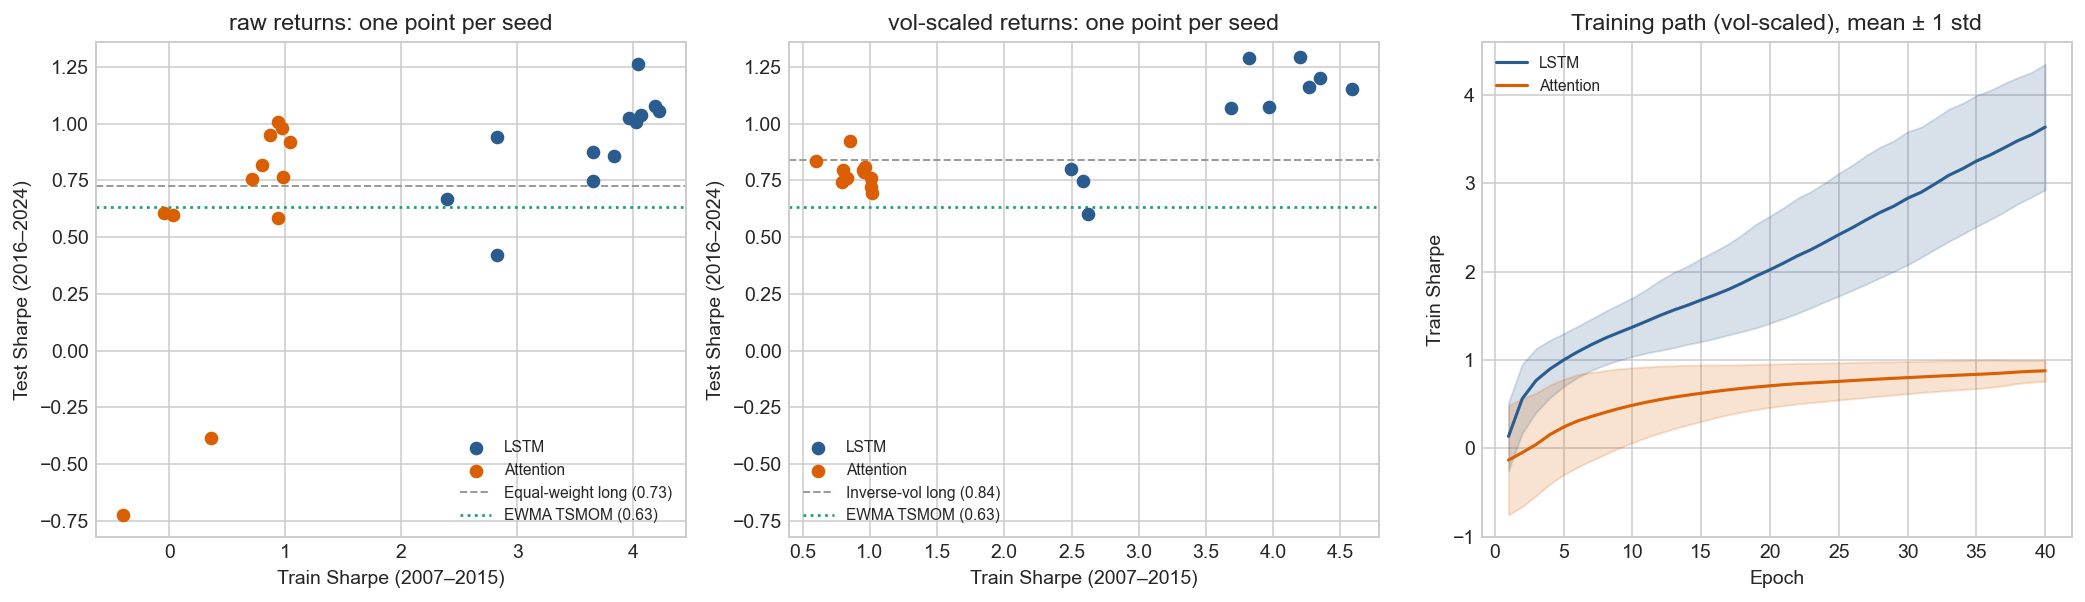

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), dpi=140)
COLORS = {"LSTM": "#2b5c8f", "Attention": "#d95f02"}
LONG_NAME = {"raw": "Equal-weight long", "vol-scaled": "Inverse-vol long"}

for ax, target in zip(axes[:2], TARGETS):
    for model_name, color in COLORS.items():
        sub = results[(results["target"] == target) & (results["model"] == model_name)]
        ax.scatter(sub["train_sr"], sub["test_sr"], color=color, s=36, label=model_name, zorder=3)
    ax.axhline(baselines[LONG_NAME[target]], color="#999999", ls="--", lw=1, label=f"{LONG_NAME[target]} ({baselines[LONG_NAME[target]]:.2f})")
    ax.axhline(baselines["EWMA TSMOM"], color="#1b9e77", ls=":", lw=1.4, label=f"EWMA TSMOM ({baselines['EWMA TSMOM']:.2f})")
    ax.set_xlabel("Train Sharpe (2007–2015)")
    ax.set_ylabel("Test Sharpe (2016–2024)")
    ax.set_title(f"{target} returns: one point per seed")
    ax.legend(fontsize=8, loc="best")
axes[1].sharey(axes[0])

ax = axes[2]
ep = np.arange(1, EPOCHS + 1)
for model_name, color in COLORS.items():
    hist = np.array(histories[("vol-scaled", model_name)])
    h_mu, h_sd = hist.mean(axis=0), hist.std(axis=0)
    ax.plot(ep, h_mu, color=color, lw=1.6, label=model_name)
    ax.fill_between(ep, h_mu - h_sd, h_mu + h_sd, color=color, alpha=0.18)
ax.set_xlabel("Epoch")
ax.set_ylabel("Train Sharpe")
ax.set_title("Training path (vol-scaled), mean ± 1 std")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 4. Seed ensembles, costs, and a test against the long book

Seed variance has a standard remedy: average the positions of all twelve networks and trade the average. That is one more strategy, not twelve, so it can be tested like the linear rules in the companion notebooks.

Two things are checked for each ensemble. **Costs**: the networks re-size every day, so each ensemble is charged 2 bp per unit of notional traded and its break-even cost is reported. **The right benchmark**: the networks are long two-thirds of the time or more in a window where a long-only book earned a Sharpe of 0.7–0.8. The Jobson–Korkie test (Memmel correction) therefore compares each ensemble with the long book under the same return definition, not with zero.

In [7]:
def sharpe_difference_test(a: np.ndarray, b: np.ndarray):
    """Jobson-Korkie test of equal Sharpe ratios with Memmel (2003) correction."""
    T = len(a)
    sr_a, sr_b = a.mean() / a.std(ddof=1), b.mean() / b.std(ddof=1)
    rho = np.corrcoef(a, b)[0, 1]
    theta = (2 * (1 - rho) + 0.5 * (sr_a ** 2 + sr_b ** 2 - 2 * rho ** 2 * sr_a * sr_b)) / T
    z = (sr_a - sr_b) / np.sqrt(theta)
    return z, 2 * stats.norm.sf(abs(z)), rho


ens_rows = {}
for (target, model_name), pos_list in positions.items():
    spec = TARGETS[target]
    ens_pos = np.mean(pos_list, axis=0)
    gross, net, turnover = net_of_costs(ens_pos, spec)
    bench = long_books[target].to_numpy()
    z, p, rho = sharpe_difference_test(gross, bench)
    z_net, p_net, _ = sharpe_difference_test(net, bench)
    daily_turnover = turnover / TRADING_DAYS
    ens_rows[(target, model_name)] = {
        "Seed mean test SR": f"{results[(results.target == target) & (results.model == model_name)].test_sr.mean():.2f}",
        "Ensemble test SR": f"{annualized_sharpe_np(gross):.2f}",
        f"Ensemble SR net of {COST_BPS:.0f} bp": f"{annualized_sharpe_np(net):.2f}",
        "Turnover (x NAV / yr)": f"{turnover:.1f}",
        "Break-even cost (bp)": f"{1e4 * gross.mean() / daily_turnover:.1f}",
        "Long-book SR": f"{annualized_sharpe_np(bench):.2f}",
        "Corr. to long book": f"{rho:.2f}",
        "JK p vs long (gross)": f"{p:.3f}",
        "JK p vs long (net)": f"{p_net:.3f}",
    }
display(pd.DataFrame(ens_rows))

raw           vol-scaled          
                          LSTM Attention       LSTM Attention
Seed mean test SR         0.91      0.57       1.11      0.78
Ensemble test SR          1.01      0.96       1.14      0.84
Ensemble SR net of 2 bp   0.86      0.86       0.94      0.72
Turnover (x NAV / yr)     13.3      21.7        9.6      23.9
Break-even cost (bp)      12.7      20.3       11.8      14.3
Long-book SR              0.73      0.73       0.84      0.84
Corr. to long book        0.14      0.70       0.32      0.89
JK p vs long (gross)     0.526     0.387      0.462     0.989
JK p vs long (net)       0.778     0.609      0.796     0.468

### What this does and does not show

Twelve seeds per cell, nothing else changed:

| Returns | Model | Train Sharpe | Test Sharpe (range; mean, std) | Net of 2 bp | Test days long |
|---|---|---|---|---|---|
| raw | LSTM | 2.40 to 4.22 | 0.42 to 1.26 (0.91, 0.22) | 0.77 | 66% |
| raw | Attention | −0.40 to 1.04 | −0.72 to 1.01 (0.57, 0.55) | 0.50 | 74% |
| vol-scaled | LSTM | 2.49 to 4.59 | 0.60 to 1.49 (1.11, 0.28) | 0.92 | 63% |
| vol-scaled | Attention | 0.60 to 1.01 | 0.69 to 0.92 (0.78, 0.06) | 0.65 | 89% |

Test-window baselines on the same dates: equal-weight long **0.73**, inverse-vol long **0.84**, EWMA TSMOM **0.63**, SPY **0.81**.

**Seed variance is real, and part of it was the target.** On raw returns the attention model's test Sharpe runs from −0.72 to 1.01 depending only on initialization. Train it on vol-scaled returns, as the paper does, and the same architecture lands between 0.69 and 0.92. A plausible reading, not tested here, is that on raw returns the loss is dominated by the few high-volatility ETFs, so the fit hinges on how an initialization happens to treat them. The LSTM does not get the same relief: with 5,153 parameters its range is still 0.60 to 1.49 under vol scaling. A single reported number from one LSTM run is not a result.

**The stable model is stable because it learned to be long.** The vol-scaled attention network is long 89% of the time and its ensemble correlates 0.89 with the inverse-vol long book, at the same Sharpe (0.84, Jobson–Korkie $p = 0.99$). After 2 bp of costs it is below that book (0.72).

**The LSTM ensemble is the interesting row, and it is not significant.** Averaging twelve seeds gives a test Sharpe of 1.14 (vol-scaled) with a correlation of only 0.32 to the long book, so it is doing something other than holding the market. But the gap to the long book's 0.84 has a Jobson–Korkie $p$ of 0.46, and 2 bp of costs take it to 0.94 ($p = 0.80$). Its break-even cost is about 12 bp. Eight years of ten ETFs cannot separate a Sharpe of 1.1 from 0.8.

**The LSTM train Sharpes are not comparable to anything else in this repo.** A free position in $(-1,1)$ fit full-batch on 2,139 days prints an in-sample Sharpe of 2.4–4.6. The drop to roughly 1 out of sample is the size of the overfit.

Neither architecture is claimed to beat a long-only book or EWMA TSMOM. There is one calendar split, one test window that happened to reward being long, and no validation set, early stopping or hyperparameter search. Lim et al. and Wood et al. trained on a futures panel this repo does not have.